# 01 — Per-cell image features: what was extracted, and does it look right?

Phase 1 output (`scripts/01_extract_features.py` → `data/features/<section>.parquet`): for every cell in the
18 annotated spinal-cord sections (run5/run6) and each of the 4 multimodal-segmentation channels:

| family | what | why it could carry biology |
|---|---|---|
| intensity × compartment | mean / p50 / p90 / p99 (+ integrated) in **nucleus, cytoplasm, 1 µm rim, 2 µm outer ring, 10 µm territory** | protein/RNA abundance and *where* it sits; ring/territory = extracellular context (neuropil, vessel wall) |
| radial profile | 5 bins centre→edge, ÷ cell mean | perinuclear vs peripheral distribution |
| polarity | intensity-weighted centroid offset (vs shape centroid / nucleus), direction | leukocyte polarisation, migration |
| texture | Haralick on per-cell rescaled levels (DAPI on chromatin only) | chromatin condensation, punctate vs diffuse |
| morphology | cell/nucleus area, shape, nucleus:cell ratio, nucleus offset | cell size, process-bearing vs round |

This notebook checks coverage and technical concordance, shows where each stain lives, and gives a first look
at cells. Intensities here are **raw** (no background correction — that is notebook 02).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from skimage.segmentation import find_boundaries

from beyondboundaries import data, plotting
from beyondboundaries.io import XeniumBundle, find_bundles

plotting.style()
SRC = "notebooks/01_feature_overview.ipynb"
OUT = ROOT / "results" / "01_features"
OUT.mkdir(parents=True, exist_ok=True)
cfg = data.load_config()
CH = data.CHANNELS
SEG = plotting.SEG_SHORT

In [2]:
f = data.load_features(cfg, annotated_only=False)
f["seg"] = f.segmentation_method.map(SEG)
f["annotated"] = f.Anno_L1_curated.notna()
print(f.shape)

(537716, 218)


## Coverage
Every Xenium cell gets features; the annotated object kept a subset (QC filtering upstream).

In [3]:
cov = f.groupby("section_id").agg(cells=("annotated", "size"), annotated=("annotated", "sum"),
                                   truncated=("truncated", "sum"))
cov["frac_annotated"] = (cov.annotated / cov.cells).round(3)
cov.loc["total"] = cov.sum(numeric_only=True)
cov.loc["total", "frac_annotated"] = round(cov.loc["total", "annotated"] / cov.loc["total", "cells"], 3)
cov.to_csv(OUT / "coverage.csv")
cov

,cells,annotated,truncated,frac_annotated
section_id,,,,
run5_C2_G1_Bot_0088858,33404.0,33110.0,0.0,0.991
run5_C2_G1_Mid_0088858,26847.0,26690.0,0.0,0.994
run5_C2_G1_Top_0088858,22520.0,22153.0,0.0,0.984
run5_C2_G2_Bot_0088858,36506.0,22100.0,0.0,0.605
run5_C2_G2_Mid_0088858,19692.0,19594.0,0.0,0.995
run5_C2_G2_Top_0088858,24381.0,18263.0,0.0,0.749
run5_C2_G3_Bot_0088870,27932.0,17854.0,0.0,0.639
run5_C2_G3_Mid_0088870,24298.0,24049.0,0.0,0.990
run5_C2_G3_Top_0088870,36636.0,35653.0,0.0,0.973


> **Finding — coverage.** 537,716 cells in 18 sections got features; 500,379 (93.1 %) are in the annotated object.
> Three sections lost 25–40 % of cells to upstream QC (C2_G2_Bot, C2_G2_Top, C2_G3_Bot). No cell was truncated by
> the tiling.

Cells not in the annotation: are they different (low transcript QC failures)?

In [4]:
f.groupby("annotated")[["transcript_counts", "n_genes", "morph_cell_area_um2"]].median()

,transcript_counts,n_genes,morph_cell_area_um2
annotated,,,
False,629.0,401.0,54.774532
True,973.0,558.0,65.928123


> **Finding — the cells left out are QC-poor**: median 629 vs 973 transcripts and 401 vs 558 genes in annotated cells,
> and they are smaller. The analysis uses annotated cells only.

## Technical concordance with Xenium's own tables

max centroid diff µm: 0.277 | area ratio range: [1.0, 1.0]


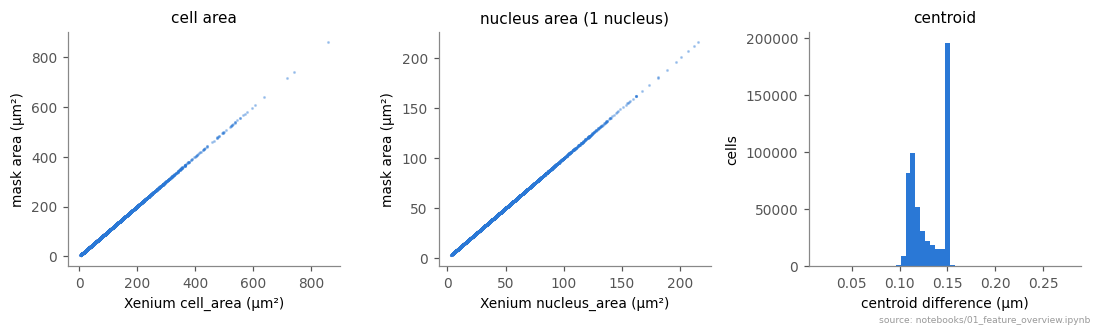

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3))
sub = f.sample(20000, random_state=0)
ax[0].scatter(sub.cell_area, sub.morph_cell_area_um2, s=1, c=plotting.CATEGORICAL[0], alpha=0.3, rasterized=True)
ax[0].set(xlabel="Xenium cell_area (µm²)", ylabel="mask area (µm²)", title="cell area")
m = sub.nucleus_count == 1
ax[1].scatter(sub.nucleus_area[m], sub.morph_nuc_area_um2[m], s=1, c=plotting.CATEGORICAL[0], alpha=0.3, rasterized=True)
ax[1].set(xlabel="Xenium nucleus_area (µm²)", ylabel="mask area (µm²)", title="nucleus area (1 nucleus)")
err = np.hypot(f.centroid_x_px * 0.2125 - f.x_centroid, f.centroid_y_px * 0.2125 - f.y_centroid)
ax[2].hist(err, bins=50, color=plotting.CATEGORICAL[0])
ax[2].set(xlabel="centroid difference (µm)", ylabel="cells", title="centroid")
fig.tight_layout()
plotting.save_fig(fig, "concordance", OUT, SRC)
print("max centroid diff µm:", err.max().round(3), "| area ratio range:",
      (f.morph_cell_area_um2 / f.cell_area).agg(["min", "max"]).round(4).tolist())

> **Finding — extraction matches Xenium exactly.** Mask areas equal Xenium `cell_area` (ratio 1.000 for every cell);
> nucleus areas match for single-nucleus cells; centroids agree within 0.28 µm.

## Feature catalogue and missingness
NaNs are structural: no nucleus → nuclear features NaN; cells fully surrounded by other cells → no ring.

In [6]:
fam = data.feature_families(f.columns)
cat = pd.DataFrame({"family": fam, "nan_frac": f[fam.index].isna().mean()})
cat.groupby("family").agg(n_features=("nan_frac", "size"), max_nan_frac=("nan_frac", "max")).round(3)

,n_features,max_nan_frac
family,,
intensity: cell,20,0.000
intensity: cyto,20,0.007
intensity: nuc,20,0.006
intensity: rim,20,0.000
intensity: ring,16,0.022
intensity: terr,16,0.022
morphology,14,0.006
polarity,16,0.008
radial profile,20,0.003


In [7]:
print("cells without nucleus:", (f.nucleus_count == 0).mean().round(4),
      "| by segmentation method:", f.groupby("seg").nucleus_count.apply(lambda s: (s == 0).mean()).round(3).to_dict())
print("cells without outer ring:", f.ring_npx.eq(0).mean().round(4))

cells without nucleus: 0.0055 | by segmentation method: {'boundary': 0.314, 'interior (18S)': 0.0, 'nucleus exp.': 0.0}
cells without outer ring: 0.0217


> **Finding — missing values are structural, not errors.** 0.55 % of cells have no nucleus (31 % of
> boundary-segmented cells); 2.2 % have no outer ring because they are completely surrounded by other cells.

## Where does each stain live?
Median compartment intensity relative to the whole-cell mean (raw, per cell, then median over cells).
18S defined ~95 % of the masks, so its cell-vs-ring contrast is partly by construction.

,dapi,bnd,r18s,smavim
nuc,1.83,0.72,0.88,0.63
cyto,0.21,1.22,1.10,1.27
rim,0.44,1.18,1.00,1.21
ring,0.04,1.29,0.22,0.91
terr,0.04,1.27,0.21,0.90


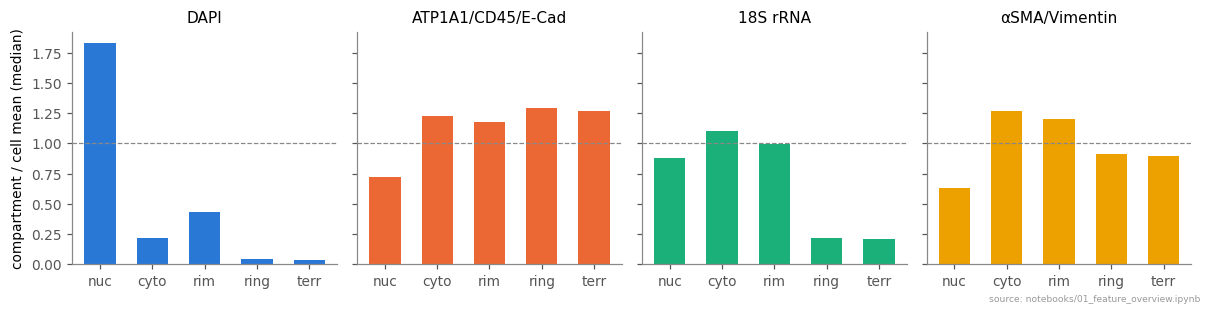

In [8]:
comps = ["nuc", "cyto", "rim", "ring", "terr"]
rel = pd.DataFrame({ch: [(f[f"{ch}_{c}_mean"] / f[f"{ch}_cell_mean"]).median() for c in comps] for ch in CH},
                   index=comps)
fig, axs = plt.subplots(1, 4, figsize=(11, 2.8), sharey=True)
for ax, ch in zip(axs, CH):
    ax.bar(comps, rel[ch], color=plotting.CHANNEL_COLORS[ch], width=0.6)
    ax.axhline(1, color="#888888", lw=0.8, ls="--")
    ax.set_title(plotting.CHANNEL_LABELS[ch])
axs[0].set_ylabel("compartment / cell mean (median)")
fig.tight_layout()
plotting.save_fig(fig, "compartment_profile", OUT, SRC)
rel.round(2)

> **Finding — each stain has its own compartment.** DAPI is nuclear (1.83× the cell mean). **ATP1A1/CD45/E-Cad is
> *higher outside* cells (ring 1.29×)** — it labels neuropil, not cell membranes. 18S is confined to cells (ring
> 0.22×; partly by construction, since 18S drew ~95 % of the masks). αSMA/Vim is cytoplasmic (1.27×).

## Raw intensity per section and segmentation method
Section-to-section offsets here are what notebook 02 removes.

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/01_features/raw_intensity_by_section_segmethod.png')

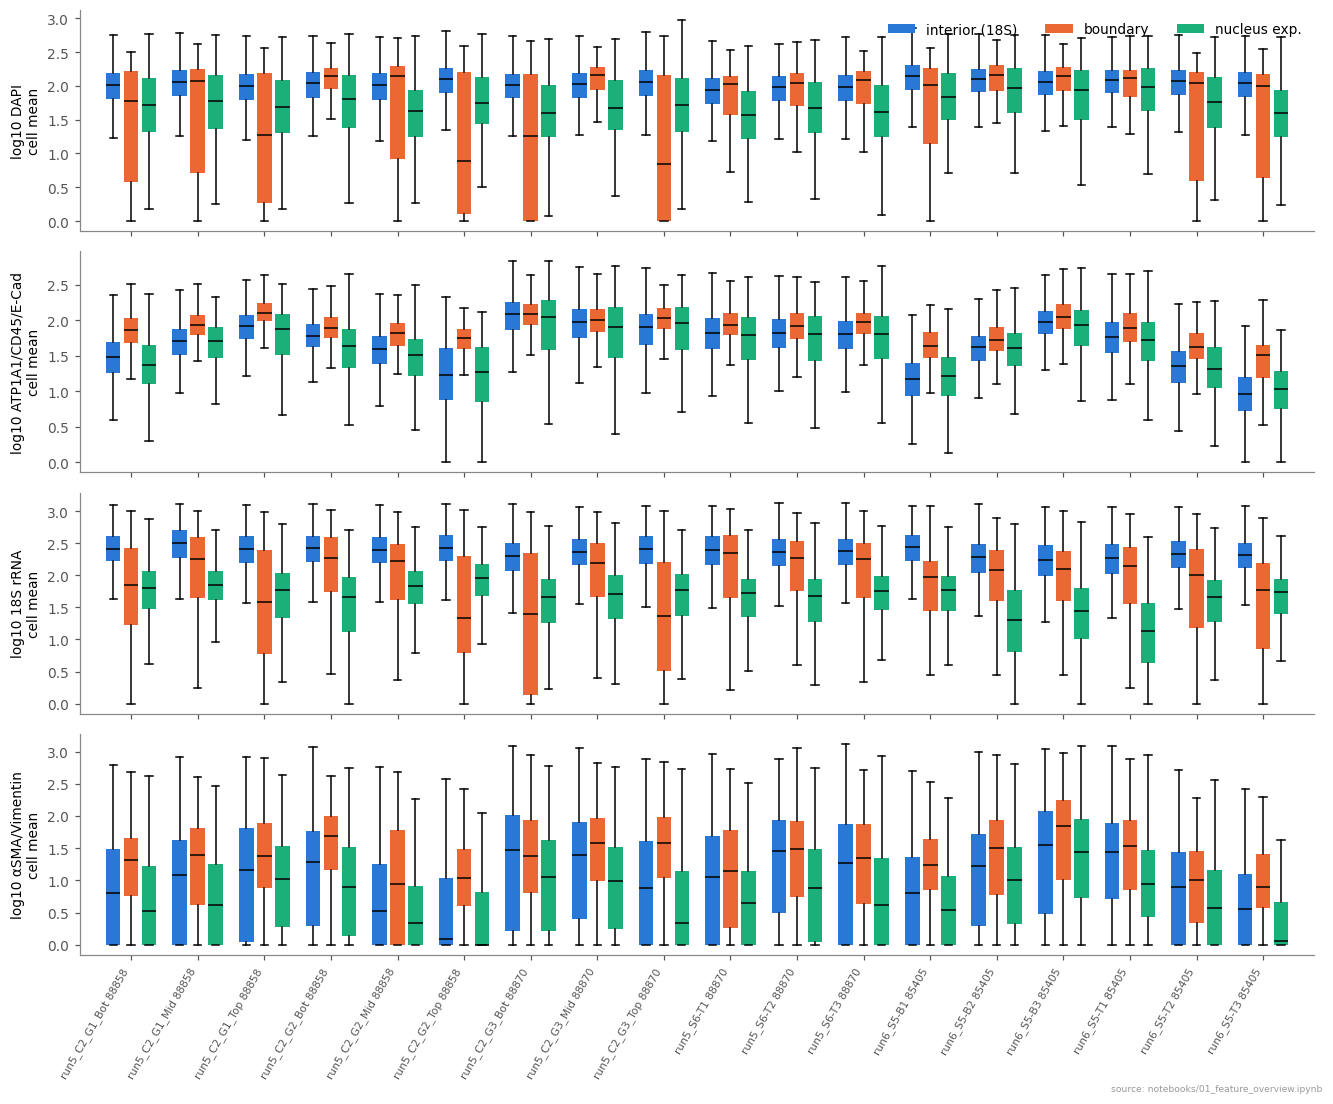

In [9]:
fig, axs = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
secs = sorted(f.section_id.unique())
segs = ["interior (18S)", "boundary", "nucleus exp."]
for ax, ch in zip(axs, CH):
    for k, s in enumerate(segs):
        vals = [np.log10(f.loc[(f.section_id == sec) & (f.seg == s), f"{ch}_cell_mean"].clip(lower=1)) for sec in secs]
        bp = ax.boxplot(vals, positions=np.arange(len(secs)) + (k - 1) * 0.27, widths=0.22, showfliers=False,
                        patch_artist=True, medianprops=dict(color="black", lw=1))
        for b in bp["boxes"]:
            b.set(facecolor=plotting.CATEGORICAL[k], edgecolor="none")
    ax.set_ylabel(f"log10 {plotting.CHANNEL_LABELS[ch]}\ncell mean")
axs[-1].set_xticks(range(len(secs)), [s.replace("_00", " ") for s in secs], rotation=60, ha="right", fontsize=7)
axs[0].legend([plt.Rectangle((0, 0), 1, 1, fc=plotting.CATEGORICAL[k]) for k in range(3)], segs, ncol=3, loc="upper right")
fig.tight_layout()
plotting.save_fig(fig, "raw_intensity_by_section_segmethod", OUT, SRC)

> **Finding — raw intensities differ strongly between sections** for the ATP1A1 and αSMA/Vim channels (and, less, by
> segmentation method). This is what notebook 02 normalises.

## First look at biology (raw, unnormalised): channel means by cell type
z-scored across cell types per feature; a teaser for the Phase 3 sanity atlas.

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/01_features/celltype_raw_heatmap.png')

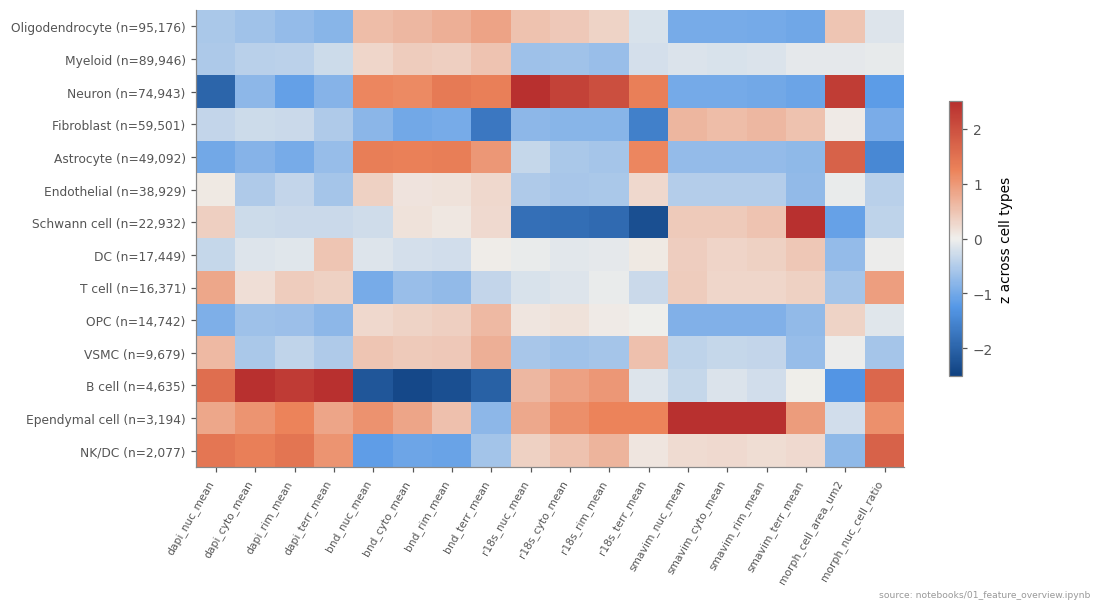

In [10]:
a = f[f.annotated & ~f.Anno_L1_curated.isin(["Doublet", "T_B_doublet"])]
feat = [f"{ch}_{c}_mean" for ch in CH for c in ("nuc", "cyto", "rim", "terr")] + \
       ["morph_cell_area_um2", "morph_nuc_cell_ratio"]
med = a.groupby("Anno_L1_curated", observed=True)[feat].median()
n = a.Anno_L1_curated.value_counts()
med = med.loc[n[n >= 200].index]
z = (med - med.mean()) / med.std()
fig, ax = plt.subplots(figsize=(10, 5.5))
im = ax.imshow(z.values, cmap=plotting.DIV, vmin=-2.5, vmax=2.5, aspect="auto")
ax.set_xticks(range(len(feat)), feat, rotation=60, ha="right", fontsize=7)
ax.set_yticks(range(len(z)), [f"{i} (n={n[i]:,})" for i in z.index], fontsize=8)
fig.colorbar(im, ax=ax, label="z across cell types", shrink=0.6)
fig.tight_layout()
plotting.save_fig(fig, "celltype_raw_heatmap", OUT, SRC)

> **Finding — known biology is already visible in raw data:** ependymal cells are the brightest in αSMA/Vim
> (vimentin⁺ ependyma), neurons have the most 18S (ribosome-rich, Nissl-like) and are the largest, fibroblasts are
> αSMA/Vim-high, Schwann cells are 18S-low. **Leukocytes are *dim* in the boundary channel**, not CD45-bright — tested
> properly in notebook 03.

## Cell gallery
Random cells per type from one section; composite DAPI (blue) / ATP1A1-CD45-ECad (orange) / 18S (green) /
αSMA-Vim (magenta), cell outline white, nucleus outline grey. 30 µm crops, identical contrast across tiles.

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/01_features/cell_gallery.png')

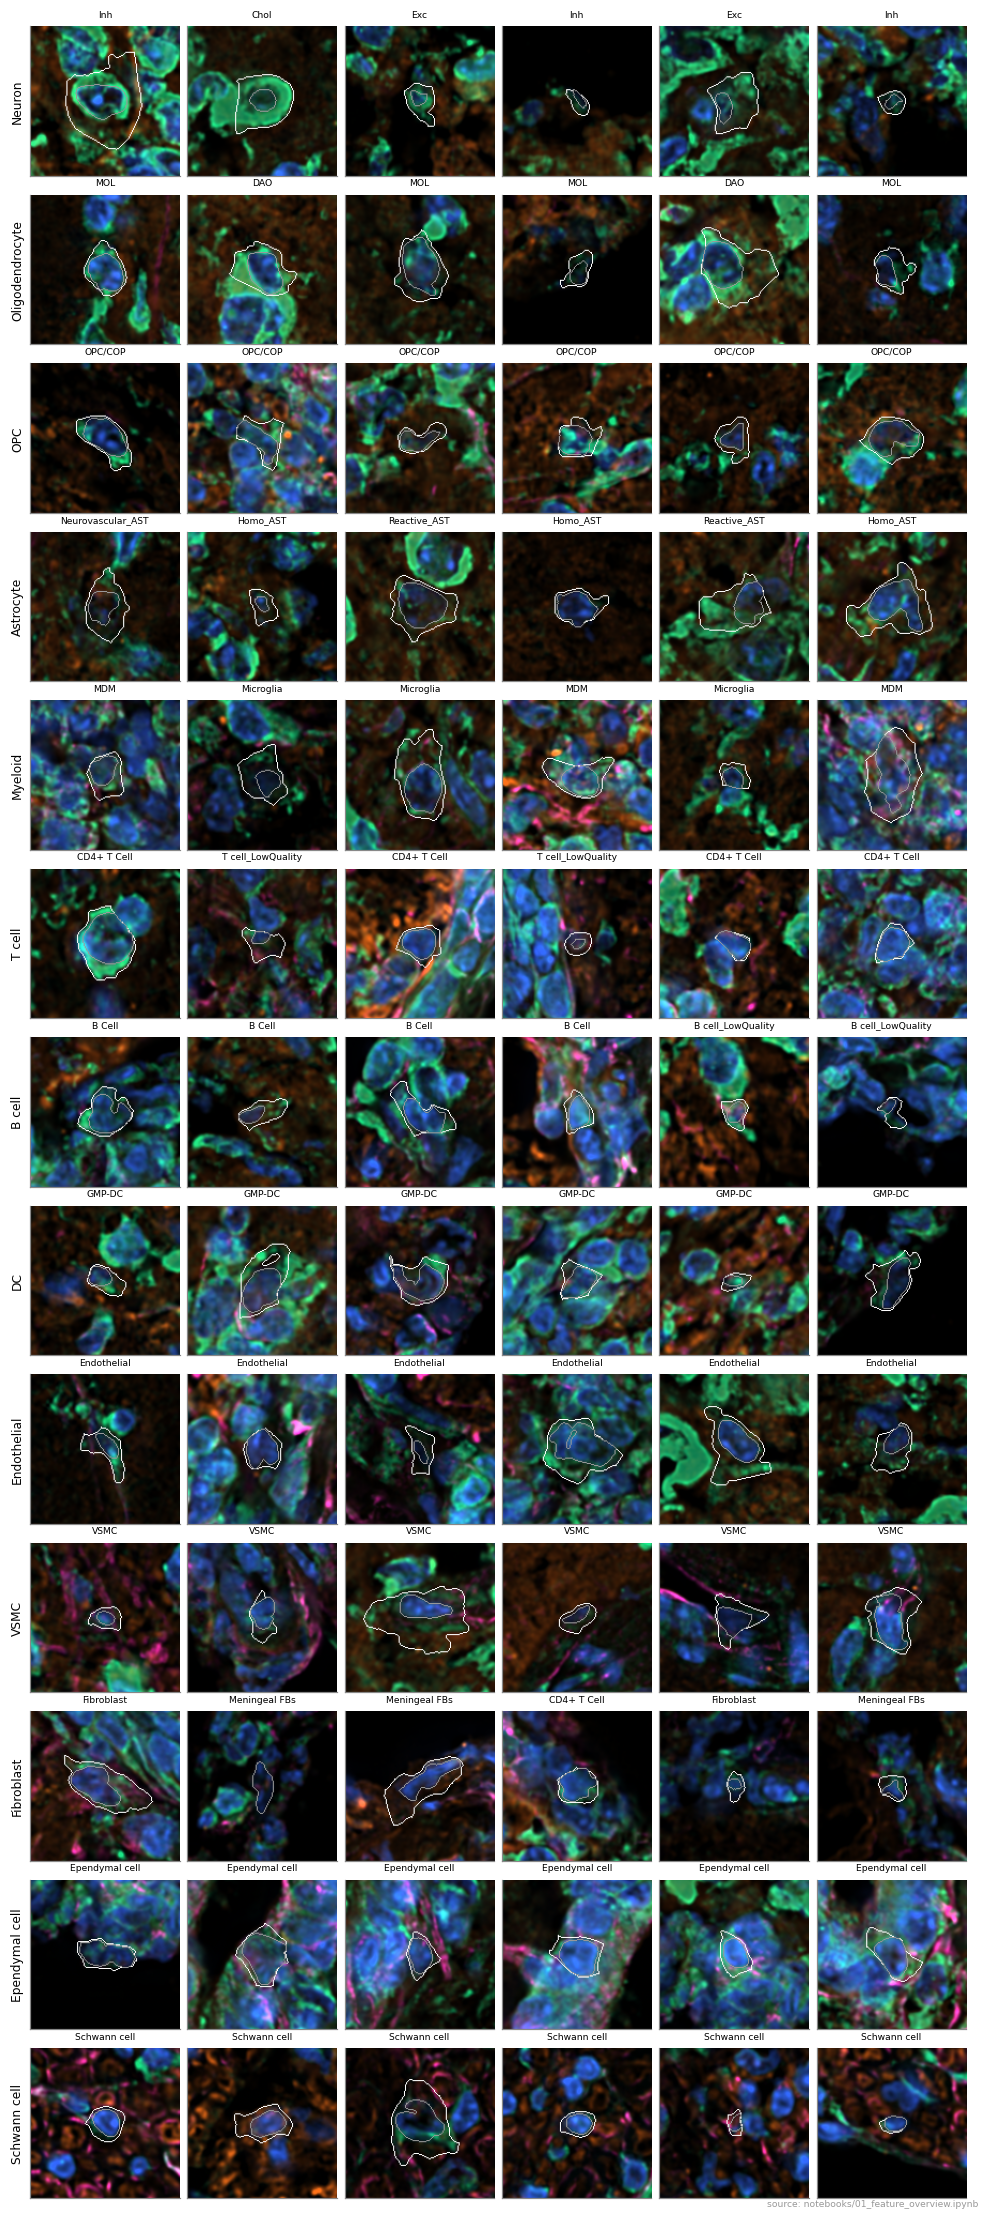

In [11]:
bundles = find_bundles(cfg)
GAL_SEC = "run5_C2_G1_Mid_0088858"
b = XeniumBundle(bundles[GAL_SEC])
g = a[a.section_id == GAL_SEC]
types = [t for t in ["Neuron", "Oligodendrocyte", "OPC", "Astrocyte", "Myeloid", "T cell", "B cell", "DC",
                     "Endothelial", "VSMC", "Fibroblast", "Ependymal cell", "Schwann cell"] if (g.Anno_L1_curated == t).sum() >= 6]
half = int(15 / 0.2125)
# common contrast from section-level raw percentiles
lo = [np.percentile(a[f"{ch}_terr_p50"].dropna(), 5) for ch in CH]
hi = [np.percentile(a[f"{ch}_cell_p99"].dropna(), 99) for ch in CH]
fig, axs = plt.subplots(len(types), 6, figsize=(9, 1.55 * len(types)))
for r, t in enumerate(types):
    cells = g[g.Anno_L1_curated == t].sample(6, random_state=1)
    for c, (cid, row) in enumerate(cells.iterrows()):
        y, x = int(row.centroid_y_px), int(row.centroid_x_px)
        img, cm, nm = b.read_window(y - half, x - half, 2 * half, 2 * half)
        rgb = plotting.composite(img, CH, lo, hi)
        lab = cm[half, half]
        rgb[find_boundaries(cm == lab, mode="inner")] = 1
        rgb[find_boundaries(nm == lab, mode="inner")] = 0.6
        axs[r, c].imshow(rgb)
        axs[r, c].set_xticks([]); axs[r, c].set_yticks([])
        axs[r, c].set_title(row.Anno_L2, fontsize=6)
    axs[r, 0].set_ylabel(t, fontsize=8)
fig.tight_layout(h_pad=0.3, w_pad=0.2)
plotting.save_fig(fig, "cell_gallery", OUT, SRC)

## Summary
Numbers referenced in RESULTS.md come from the tables above (coverage, concordance, compartment profile).